In [10]:
# Load libraries
library(tidyverse)
library(dplyr)
library(GGally)
library(broom)

# Adjust plot and font sizes
options(repr.plot.width = 10, repr.plot.height = 10)
set_theme(theme_gray(base_size = 16))

### Data preprocessing

In [11]:
wc <- read_csv(file = "players-selected-columns.csv")

# Remove players who've not played
wc <- wc |> filter(minutes > 0)

# Turn hybrid players into singular, prioritize first position
wc <- wc |> mutate(position = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW")))

# Remove team_country, shots_on_target per EDA
wc <- wc |> mutate(team_country = NULL, shots_on_target = NULL)

# Remove goalies from data
wc <- wc |> filter(position != "GK")

# Turn mins to hours
wc <- wc |> mutate(hours = minutes / 60, minutes = NULL)

Rows: 1248 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): team_country, position
dbl (11): age, minutes, goals, assists, cards_yellow, shots, shots_on_target...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Linear Regression

In [12]:
# Remove players that didn't score

wc_lin <- wc |> filter(goals > 0)

# Log transform on goals
wc_lin <- wc_lin |> mutate(goals = log(goals))

head(wc_lin)

position,age,goals,assists,cards_yellow,shots,fouls,offsides,interceptions,tackles_won,hours
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FW,26,0.0000000,0,0,3,1,0,0,1,4.183333
FW,26,0.0000000,0,0,2,0,0,0,1,0.750000
DF,24,0.0000000,0,0,3,4,0,1,3,5.516667
MF,35,0.6931472,1,0,6,1,1,1,2,4.366667
MF,27,0.0000000,1,1,13,9,0,9,12,12.500000
DF,28,0.0000000,0,2,3,9,0,11,10,10.133333


In [13]:
# Linreg model

wc_lin_model <- lm(formula = goals ~ ., data = wc_lin)

wc_lin_model_stat <- wc_lin_model |> tidy() |> mutate_if(is.numeric, round, 3)

wc_lin_model_stat

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.121,0.227,-0.531,0.596
positionMF,0.000,0.091,-0.005,0.996
positionFW,0.140,0.110,1.270,0.206
age,0.001,0.008,0.140,0.889
assists,0.018,0.041,0.436,0.663
cards_yellow,0.011,0.051,0.222,0.824
shots,0.048,0.008,5.801,0.000
fouls,-0.020,0.015,-1.321,0.188
offsides,0.004,0.026,0.138,0.890


### Logistic Regression

In [14]:
# Add new column indicate if player has scored or not, then remove goals

has_scored_dat <- if_else(wc$goals > 0, 1, 0)

wc_log <- wc |> mutate(has_scored = has_scored_dat, goals = NULL)

head(wc_log)

position,age,assists,cards_yellow,shots,fouls,offsides,interceptions,tackles_won,hours,has_scored
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FW,23,0,0,0,0,1,0,0,0.31666667,0
FW,26,0,0,3,1,0,0,1,4.18333333,1
MF,24,0,0,2,0,0,1,0,1.63333333,0
DF,34,0,0,0,0,0,4,3,6.00000000,0
MF,23,0,1,9,3,1,3,5,6.00000000,0
FW,23,0,0,0,0,0,0,0,0.01666667,0


In [15]:
# Logreg model 1: Binomial family

wc_log_model_1 <- glm(formula = has_scored ~ ., data = wc_log, family = binomial)

wc_log_model_1_stat <- wc_log_model_1 |> tidy(exponentiate = TRUE) |> mutate_if(is.numeric, round, 3)

# Logreg model 2: Quasibonimial family

wc_log_model_2 <- glm(formula = has_scored ~ ., data = wc_log, family = quasibinomial)

wc_log_model_2_stat <- wc_log_model_2 |> tidy(exponentiate = TRUE) |> mutate_if(is.numeric, round, 3)


wc_log_model_1_stat

wc_log_model_2_stat

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.082,0.751,-3.328,0.001
positionMF,1.672,0.282,1.823,0.068
positionFW,1.986,0.344,1.996,0.046
age,0.968,0.026,-1.265,0.206
assists,0.981,0.163,-0.115,0.908
cards_yellow,1.396,0.195,1.714,0.087
shots,1.398,0.045,7.525,0.000
fouls,0.989,0.053,-0.213,0.831
offsides,1.136,0.120,1.059,0.290


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.082,0.724,-3.449,0.001
positionMF,1.672,0.272,1.889,0.059
positionFW,1.986,0.332,2.069,0.039
age,0.968,0.025,-1.311,0.190
assists,0.981,0.158,-0.119,0.905
cards_yellow,1.396,0.188,1.776,0.076
shots,1.398,0.043,7.799,0.000
fouls,0.989,0.051,-0.221,0.825
offsides,1.136,0.116,1.098,0.273


#### Evaluation

##### Part 1: Linear Model

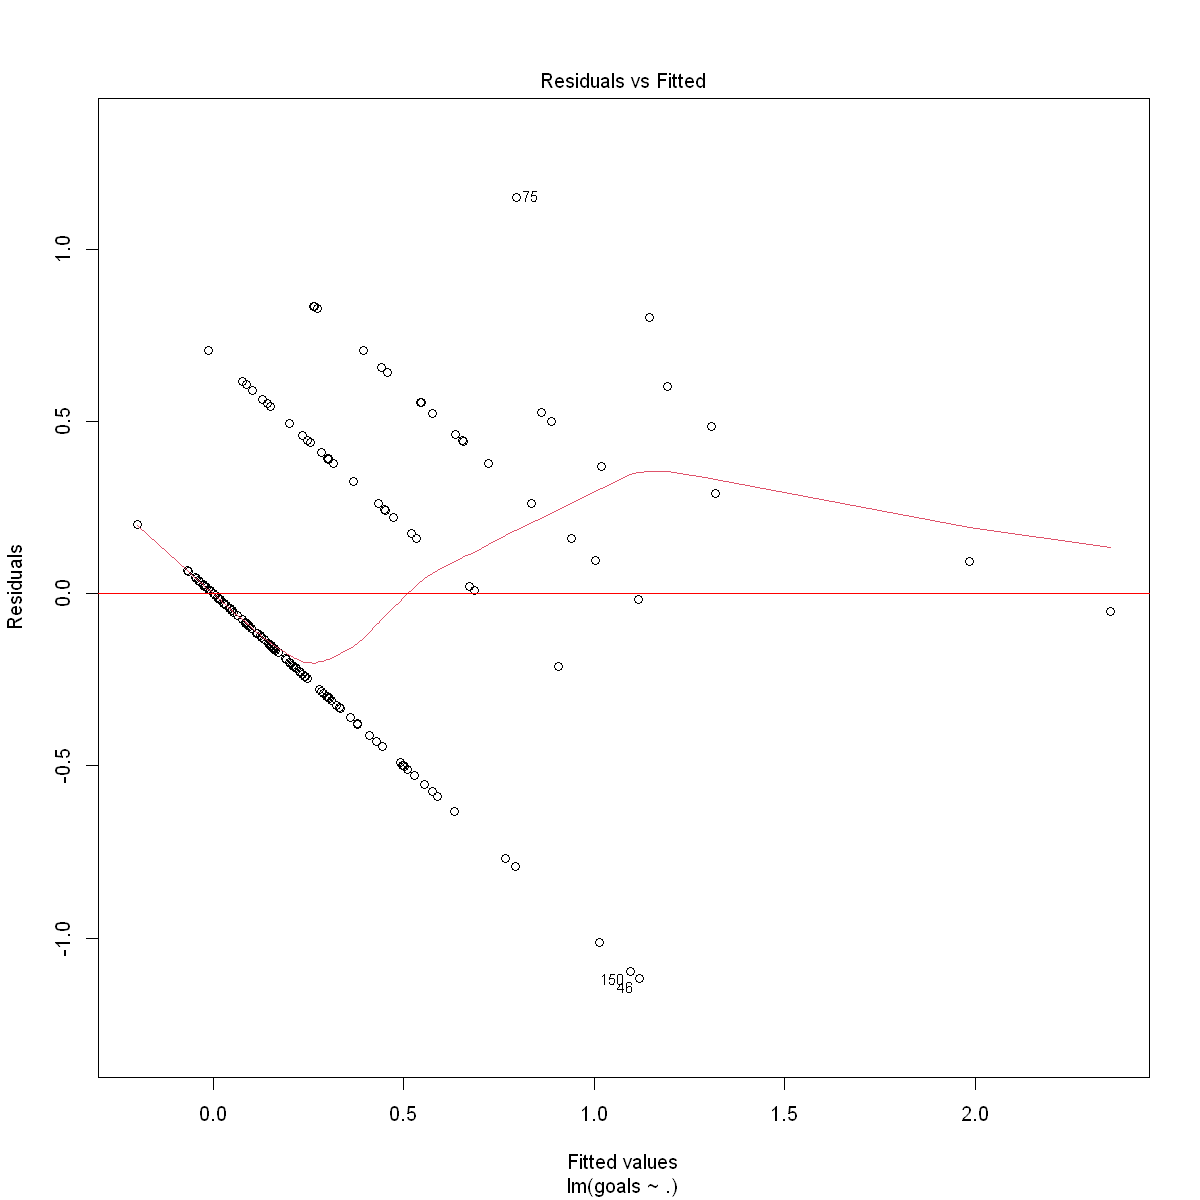

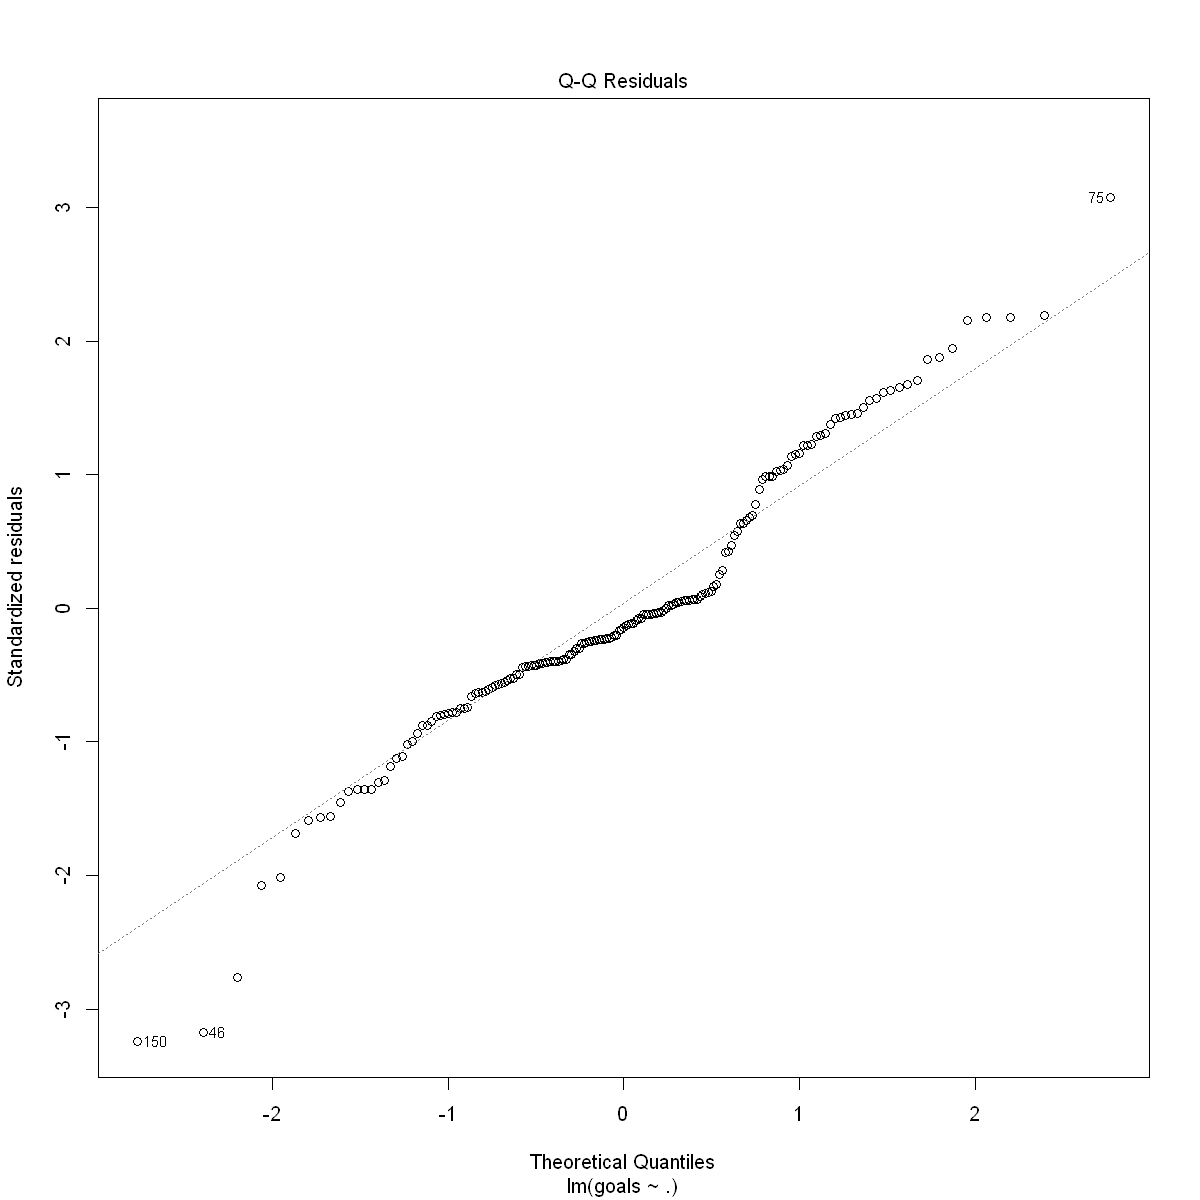

In [16]:
# Residuals
plot(wc_lin_model, which = 1)
abline(h = 0, col = "red")

# QQ plot
plot(wc_lin_model, which = 2)

##### Part 2: Logistic Regression

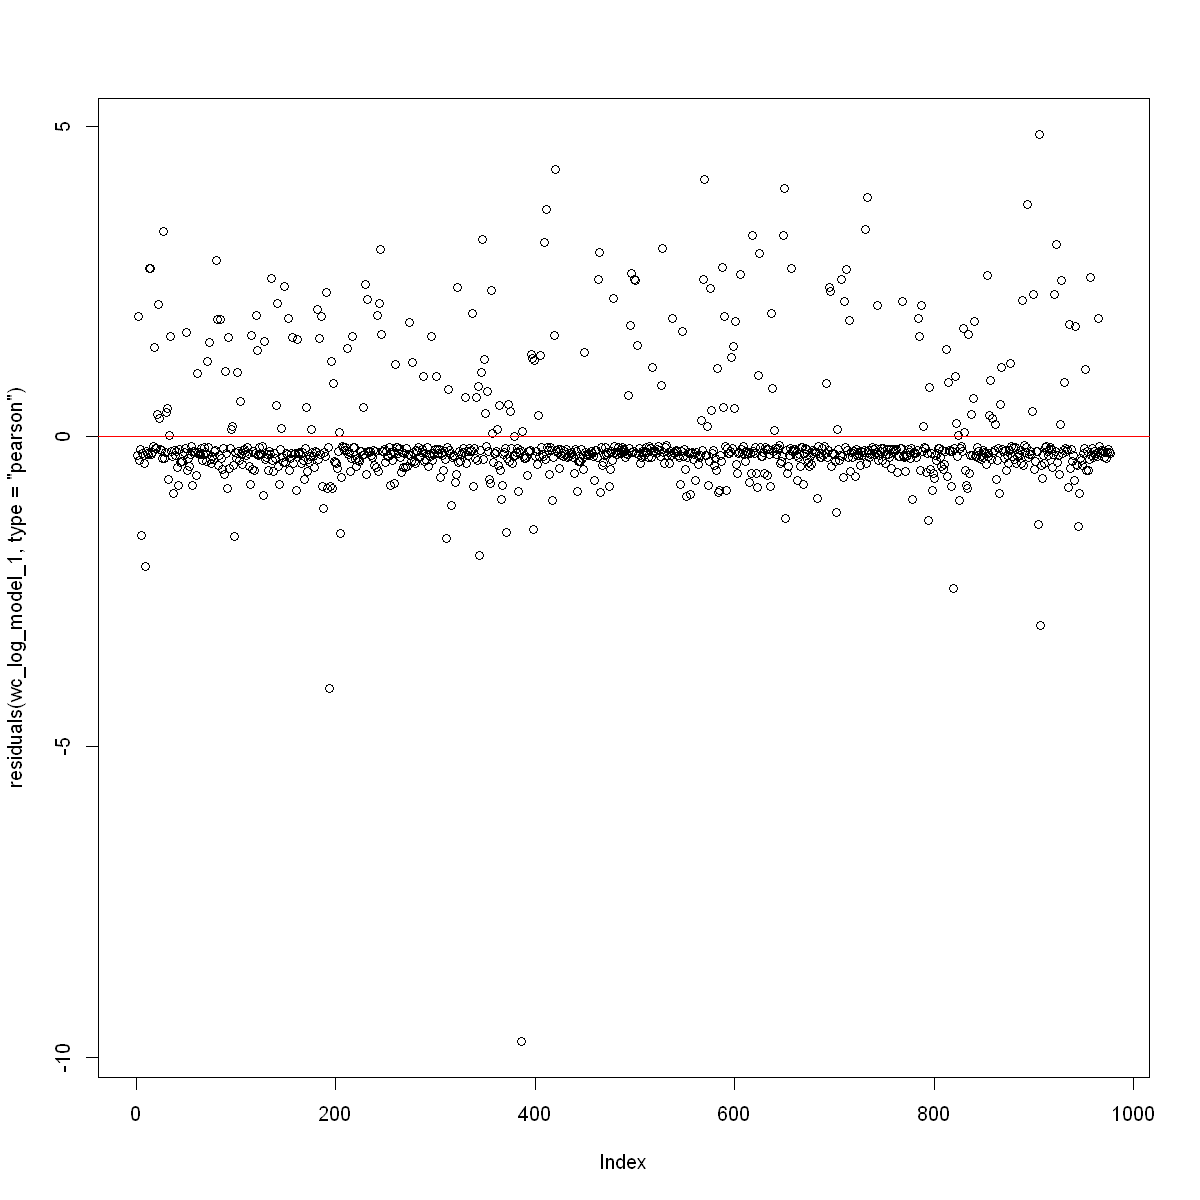

In [17]:
## Binomial family log model

# Residuals
plot(residuals(wc_log_model_1, type = "pearson"))
abline(h = 0, col = "red")


Call:
glm(formula = has_scored ~ ., family = quasibinomial, data = wc_log)

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -2.49813    0.72434  -3.449 0.000587 ***
positionMF     0.51389    0.27206   1.889 0.059205 .  
positionFW     0.68610    0.33162   2.069 0.038817 *  
age           -0.03243    0.02475  -1.311 0.190309    
assists       -0.01882    0.15751  -0.119 0.904922    
cards_yellow   0.33385    0.18798   1.776 0.076047 .  
shots          0.33526    0.04299   7.799 1.61e-14 ***
fouls         -0.01125    0.05084  -0.221 0.824936    
offsides       0.12754    0.11621   1.098 0.272691    
interceptions  0.01169    0.05805   0.201 0.840494    
tackles_won   -0.08632    0.05084  -1.698 0.089873 .  
hours          0.10411    0.07348   1.417 0.156828    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for quasibinomial family taken to be 0.9310489)

    Null deviance: 930.56  on 976  degrees of freedom
R

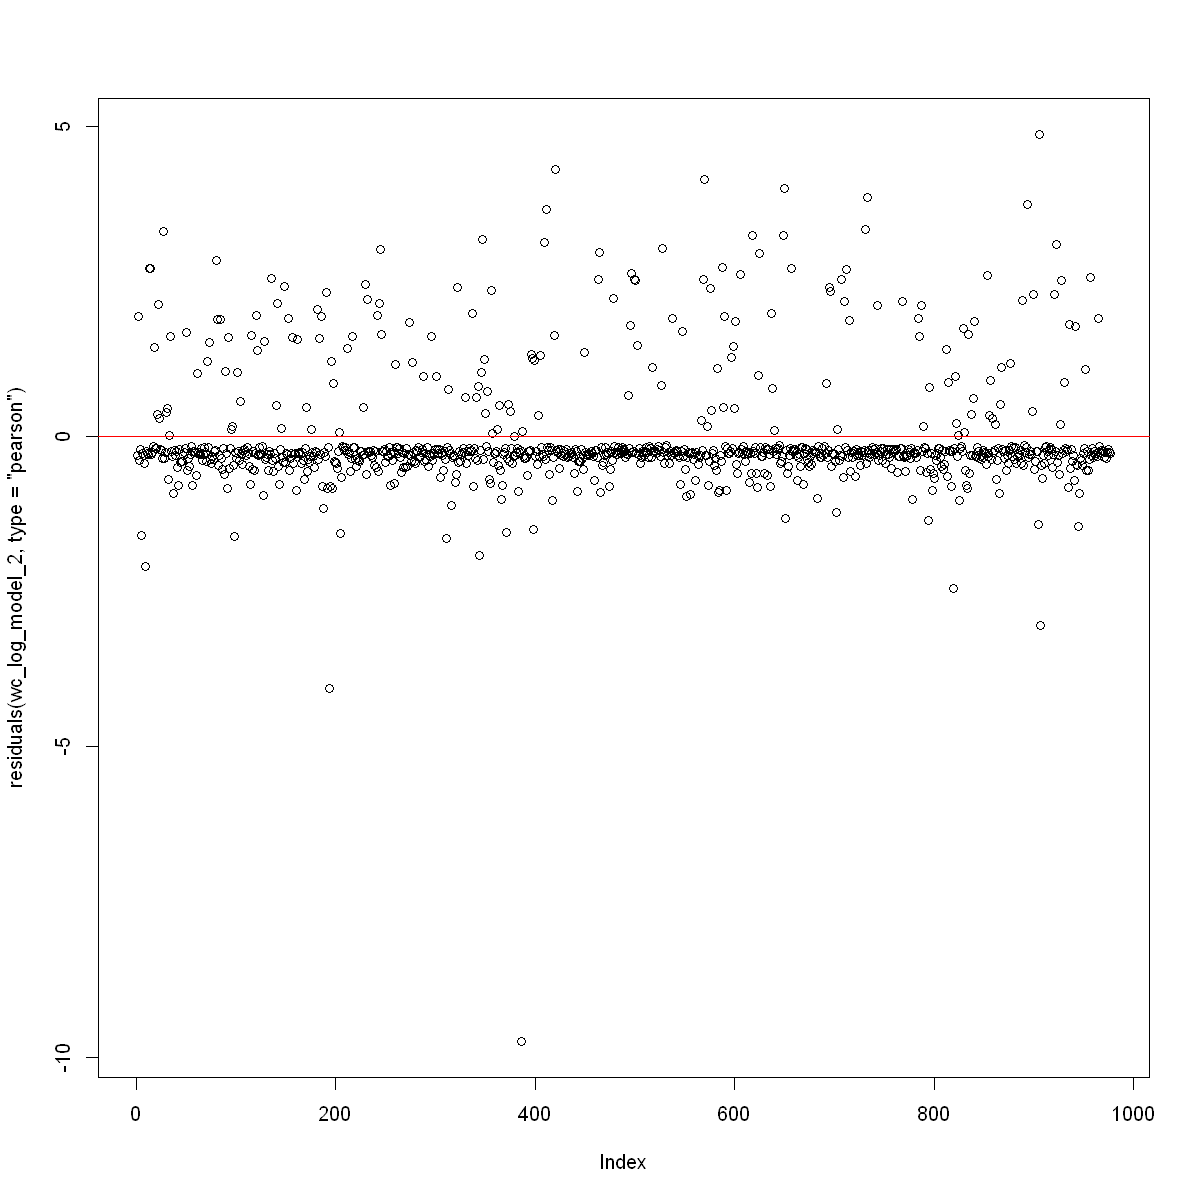

In [18]:
## Quasibinomial family log model

# Residuals
plot(residuals(wc_log_model_2, type = "pearson"))
abline(h = 0, col = "red")

summary(wc_log_model_2)